In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Train Model by EfficientNet

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)
for layer in base_model.layers:
    layer.trainable = False
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(2, activation='softmax')(x)
model = models.Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_data,
    epochs=17
)
for layer in base_model.layers[-20:]:
    layer.trainable = True
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_fine = model.fit(
    train_data,
    epochs=5
)

Epoch 1/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.6055 - loss: 0.8401
Epoch 2/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 55s 814ms/step - accuracy: 0.6550 - loss: 0.7075
Epoch 3/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 53s 789ms/step - accuracy: 0.6440 - loss: 0.7067
Epoch 4/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 55s 814ms/step - accuracy: 0.6655 - loss: 0.6705
Epoch 5/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 52s 778ms/step - accuracy: 0.6775 - loss: 0.6469
Epoch 6/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 54s 800ms/step - accuracy: 0.6930 - loss: 0.6330
Epoch 7/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 80s 773ms/step - accuracy: 0.6900 - loss: 0.6407
Epoch 8/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 53s 794ms/step - accuracy: 0.6890 - loss: 0.6370
Epoch 9/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 81s 775ms/step - accuracy: 0.6985 - loss: 0.6211
Epoch 10/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 54s 804ms/step - accuracy: 0.6980 - loss: 0.6160
Epoch 11/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 52s 782ms/step - accuracy: 0.6970 - loss: 0.6181
Epoch 12/17
67/67 ━━━━━━━━━━━━━━━━━━━━ 54s 

In [ ]:
model.save("/content/drive/MyDrive/efficientnet_flood_model.h5")

In [ ]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 121s 6s/step - accuracy: 0.6969 - loss: 0.6342
Test Accuracy: 0.696864128112793


In [ ]:
from tensorflow.keras.models import load_model

eff.model = load_model("/content/drive/MyDrive/efficientnet_flood_model.h5")

Classification Report for EfficientNet

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step
Accuracy: 0.6968641114982579


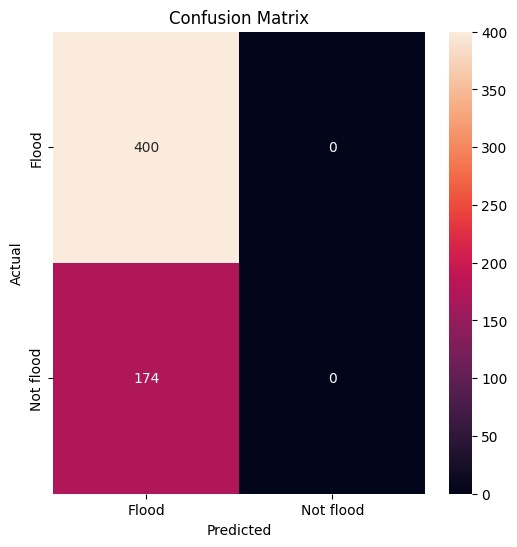


Classification Report:
              precision    recall  f1-score   support

       Flood       0.70      1.00      0.82       400
   Not flood       0.00      0.00      0.00       174

    accuracy                           0.70       574
   macro avg       0.35      0.50      0.41       574
weighted avg       0.49      0.70      0.57       574



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


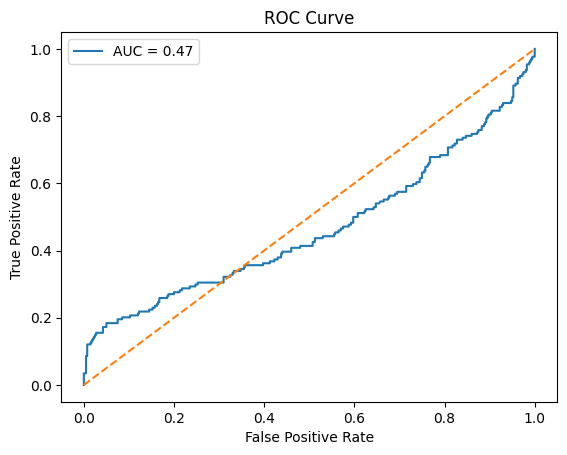

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

test_data.reset()

pred_probs = model.predict(test_data)
y_pred = np.argmax(pred_probs, axis=1)

y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

if len(class_labels) == 2:
    fpr, tpr, _ = roc_curve(y_true, pred_probs[:,1])
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()